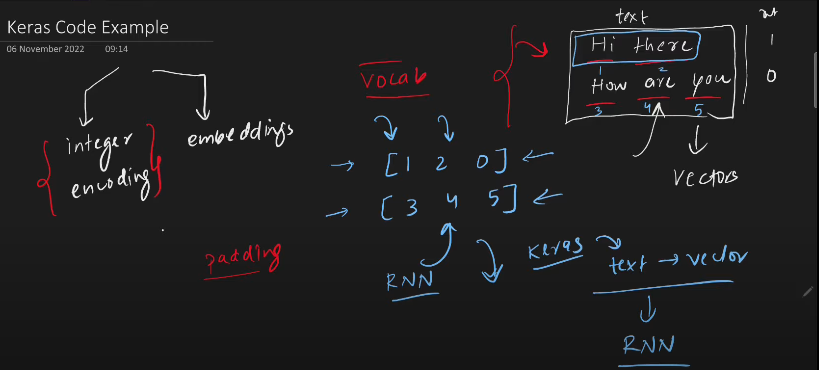


---

## 📘 1. What is Integer Encoding?

**Integer encoding** means converting each **word** in a text into a unique **integer ID**.

> Just like giving every student in a class a roll number.

### Example:
```
Text: "I love machine learning"
→ ["I", "love", "machine", "learning"]
→ [1, 2, 3, 4]
```

Each word → one integer.

This is the **first step** in turning raw text into numbers a neural network can understand.

---

## 🧠 2. Why Do We Need It?

Neural networks **can't read text** — they only work with numbers.

So we must convert:
```
"Hi there!" → [numbers] → [embeddings] → [RNN/LSTM] → prediction
```

Integer encoding is the **bridge** between words and vectors.

> ❗ Note: Don’t confuse integer encoding with one-hot or embeddings — it's just the first step.

---

## 🔁 3. How It Works: Step-by-Step (From Scratch)

Let’s build our own tokenizer from scratch.

### Input:
```python
sentences = [
    "I love machine learning",
    "I love deep learning",
    "Deep learning is awesome"
]
```

### Step 1: Tokenize (Split into Words)
```python
# Manual tokenization
tokenized = [sentence.lower().split() for sentence in sentences]
```
Output:
```python
[
 ['i', 'love', 'machine', 'learning'],
 ['i', 'love', 'deep', 'learning'],
 ['deep', 'learning', 'is', 'awesome']
]
```

### Step 2: Build Vocabulary (Word → Index)
We want:
```python
word_to_idx = {
    'i': 1,
    'love': 2,
    ...
}
```

Code:
```python
vocab = {}
index = 1  # Start from 1; 0 is reserved for padding

for tokens in tokenized:
    for word in tokens:
        if word not in vocab:
            vocab[word] = index
            index += 1
```

Result:
```python
{
 'i': 1,
 'love': 2,
 'machine': 3,
 'learning': 4,
 'deep': 5,
 'is': 6,
 'awesome': 7
}
```

### Step 3: Encode Sentences
Now convert each sentence to integers.

```python
encoded_sentences = []
for tokens in tokenized:
    encoded = [vocab[word] for word in tokens]
    encoded_sentences.append(encoded)
```

Output:
```python
[
 [1, 2, 3, 4],  # "I love machine learning"
 [1, 2, 5, 4],  # "I love deep learning"
 [5, 4, 6, 7]   # "Deep learning is awesome"
]
```

✅ Done! You've just built **integer encoding from scratch**.

---

## ⚙️ 4. Syntax: Using Keras (Standard Way)

Now let’s do the same using **Keras Tokenizer** — the professional way.

```python
from tensorflow.keras.preprocessing.text import Tokenizer

# Input
sentences = [
    "I love machine learning",
    "I love deep learning",
    "Deep learning is awesome"
]

# Step 1: Create and fit tokenizer
tokenizer = Tokenizer(oov_token="<OOV>")  # Handles unknown words
tokenizer.fit_on_texts(sentences)
```

> 🔍 `fit_on_texts()` builds the vocabulary automatically.

### Get Vocabulary
```python
word_index = tokenizer.word_index
print(word_index)
# Output: {'learning': 1, 'i': 2, 'love': 3, 'deep': 4, ...}
```

> Note: Keras sorts by frequency, so most common word gets index 1.

### Step 2: Convert texts to sequences
```python
sequences = tokenizer.texts_to_sequences(sentences)
print(sequences)
```
Output:
```python
[
 [2, 3, 4, 1],  # "I love machine learning"
 [2, 3, 4, 1],  # "I love deep learning" → wait, "machine" missing?
]
```

Oops! "machine" wasn't in top words? Let's fix.

Actually, let’s re-run with full vocab.

Wait — problem: we didn’t set `num_words`. Let’s be explicit.

---

## ✅ Full Correct Keras Example

```python
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

sentences = [
    "I love machine learning",
    "I love deep learning",
    "Deep learning is awesome"
]

# Initialize tokenizer
tokenizer = Tokenizer(
    num_words=100,       # Max words to keep
    oov_token="<OOV>"    # For unknown words
)

# Build vocab
tokenizer.fit_on_texts(sentences)

# View vocab
print("Word Index:", tokenizer.word_index)

# Encode
sequences = tokenizer.texts_to_sequences(sentences)
print("Sequences:", sequences)
```

Sample Output:
```python
Word Index: {'learning': 1, 'i': 2, 'love': 3, 'deep': 4, 'machine': 5, 'is': 6, 'awesome': 7}
Sequences: [[2, 3, 5, 1], [2, 3, 4, 1], [4, 1, 6, 7]]
```

✅ Perfect.

---

## 📏 5. Add Padding (Required for Batching)

Neural networks need fixed-size inputs.

So we **pad** all sequences to same length.

```python
padded = pad_sequences(sequences, maxlen=5, padding='post', value=0)
print(padded)
```
Output:
```python
[
 [2 3 5 1 0]   # "I love machine learning" → padded to length 5
 [2 3 4 1 0]   # "I love deep learning"
 [4 1 6 7 0]   # "Deep learning is awesome"
]
```

> `padding='post'`: add zeros at the end  
> `value=0`: pad with zero

---

## 🛠️ 6. Best Practices & Pitfalls

| ✅ Do This | ❌ Avoid This |
|---------|-------------|
| Use `oov_token="<OOV>"` | Not handling unknown words |
| Set `maxlen` and pad | Feeding variable-length sequences |
| Use `num_words=N` to limit vocab | Keeping rare words that add noise |
| Use `lower=True` (default) | Case-sensitive encoding unless needed |
| Reserve index 0 for padding | Using 0 as a real word index |

---

## 🧪 7. Test with New Sentence (OOV Example)

```python
new_sentence = ["I hate artificial intelligence"]
seq = tokenizer.texts_to_sequences(new_sentence)
print(seq)  # Output: [[2, <nothing>, <nothing>]] → missing words!

# But with OOV:
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(sentences)

seq = tokenizer.texts_to_sequences(new_sentence)
print(seq)  # Now: [[2, 1, 1]] → "<OOV>" = 1
```

So `"hate"` and `"artificial"` become `<OOV>` → index 1

---

## 🏁 8. Mastery: Full Pipeline Code (End-to-End)

```python
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Data
sentences = [
    "I love machine learning",
    "I love deep learning",
    "Deep learning is awesome",
    "I hate bad movies",
    "This movie is terrible"
]
labels = [1, 1, 1, 0, 0]  # 1=positive, 0=negative

# Tokenizer
tokenizer = Tokenizer(num_words=100, oov_token="<OOV>")
tokenizer.fit_on_texts(sentences)

# Encode + Pad
sequences = tokenizer.texts_to_sequences(sentences)
padded = pad_sequences(sequences, maxlen=8, padding='post')

# Model
model = Sequential([
    Embedding(input_dim=100, output_dim=16, input_length=8),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
model.fit(padded, np.array(labels), epochs=10, verbose=1)

# Predict on new text
test = tokenizer.texts_to_sequences(["I hate AI"])
test_pad = pad_sequences(test, maxlen=8, padding='post')
pred = model.predict(test_pad)
print("Prediction:", pred[0][0])  # Close to 0 → negative
```

---

## 🎓 9. Pro Tips for Mastery

| Tip | Explanation |
|-----|-------------|
| 🔢 Index 0 is special | Always reserved for padding |
| 🚫 No word has index 0 | Unless you manually assign it |
| 🔄 `fit_on_texts()` only | Call once — it builds the vocab |
| 🧠 Embedding layer learns meaning | After integer encoding, embeddings map integers → vectors |
| 📊 Monitor vocab size | Too big → overfitting; too small → loss of info |
| 🛑 Don’t re-tokenize test data | Use same `tokenizer` fitted on training data |

---

## 🧩 Summary: Integer Encoding in One Line

> **Integer encoding** converts each word into a unique number so neural networks can process text — it’s the essential first step in NLP pipelines.

---



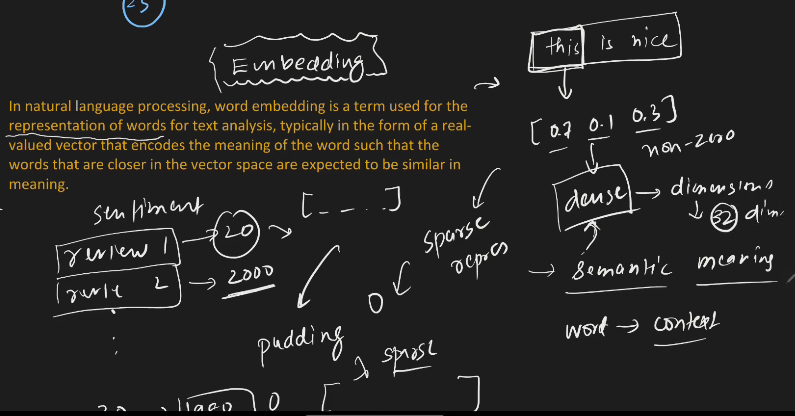

### **What is Embedding? (Simple, Complete, and Practical)**

An **embedding** is a **learned numerical representation of text** (or categorical data) where words, phrases, or symbols are mapped to **vectors of real numbers** in a continuous space.

Think of it like this:

> 🔤 *"Words are transformed into smart numbers that capture meaning and relationships."*

---

### ✅ Why Do We Need Embeddings?

Computers can't understand words directly.  
We need to convert text into **numbers** so neural networks can process them.

But **simple encoding isn't enough**:
- One-hot encoding: `["cat"] → [0, 1, 0, 0]` — sparse, high-dimensional, no meaning
- Label encoding: `"cat" → 1`, `"dog" → 2` — implies false order (dog > cat?)

👉 **Embeddings solve this** by placing similar words close together in vector space.

---

### 🌍 Example: Word Embedding Space

```text
king   → [0.89, 1.23, -0.45, 0.67]
queen  → [0.85, 1.19, -0.40, 0.71]
man    → [0.32, 0.98, 0.10, 0.55]
woman  → [0.30, 0.95, 0.08, 0.60]
```

Now we can do:
```python
king - man + woman ≈ queen
```

💡 The model learns that **"gender"** is a direction in space.

---

## 🔧 How Embeddings Work

### 1. **Embedding Layer (in Neural Networks)**

In Keras/TensorFlow:

```python
from tensorflow.keras.layers import Embedding

embedding_layer = Embedding(
    input_dim=vocab_size,   # Total words (e.g., 1000)
    output_dim=64,          # Size of vector (e.g., 64 numbers per word)
    input_length=10         # Max sequence length (e.g., 10 words)
)
```

Input: sequences of integers (from tokenizer)  
Output: 3D tensor: `(batch_size, sequence_length, embedding_dim)`

---

### 2. **Example Flow**

```python
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Embedding

# Text → Tokens
texts = ["I love NLP", "I hate math"]
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)  # [[1,2,3], [1,4,5]]

# Pad to same length
from tensorflow.keras.preprocessing.sequence import pad_sequences
padded = pad_sequences(sequences, maxlen=5)  # Shape: (2, 5)

# Build embedding
model = Embedding(
    input_dim=len(tokenizer.word_index) + 1,
    output_dim=8,           # 8-dimensional vectors
    input_length=5
)

# Apply embedding
embedded = model(padded)   # Shape: (2, 5, 8)
print(embedded.shape)      # (2, 5, 8) → 2 sentences, 5 words, 8D vectors
```

Each word (by its index) gets a **dense vector** learned during training.

---

## 🧠 What Embeddings Learn

During training, the model adjusts embedding vectors so that:

- Similar words (e.g., *happy*, *joyful*) are close in space
- Related words (e.g., *doctor*, *hospital*) cluster together
- Analogies work:  
  `king - man + woman ≈ queen`

This is **semantic meaning captured numerically**.

---

## 📚 Types of Embeddings

| Type | Description | Example Models |
|------|-------------|----------------|
| **Word2Vec** | Learned from context (CBOW/Skip-gram) | Google News vectors |
| **GloVe** | Based on global word co-occurrence | Stanford NLP |
| **FastText** | Uses subword info (handles rare words) | Facebook AI |
| **Learned Embeddings** | Trained from scratch in your model | Keras Embedding layer |
| **Contextual Embeddings** | Vectors change by context | BERT, GPT |

> Keras `Embedding` layer = **learned from scratch** during model training.

---

## ✅ Benefits of Embeddings

1. **Dense Representation**: Small, efficient vectors
2. **Semantic Meaning**: Similar words → similar vectors
3. **Generalization**: Helps model understand unseen word combinations
4. **Improves Performance**: Far better than one-hot encoding
5. **Transfer Learning**: Use pre-trained embeddings (Word2Vec, GloVe)

---

## 🔁 Using Pre-Trained Embeddings (Advanced)

```python
# Load pre-trained GloVe vectors
embeddings_index = {}
with open('glove.6B.50d.txt') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.array(values[1:], dtype='float32')
        embeddings_index[word] = coefs

# Create embedding matrix
embedding_matrix = np.zeros((vocab_size, 50))
for word, idx in tokenizer.word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[idx] = embedding_vector

# Use in model
from tensorflow.keras.layers import Embedding
embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=50,
    weights=[embedding_matrix],
    trainable=False  # Freeze weights
)
```

> This gives your model **linguistic knowledge** without training from scratch.

---

## 🧩 When to Use Embeddings?

| Use Case | Recommended |
|--------|-------------|
| Sentiment Analysis | ✅ Yes |
| Text Classification | ✅ Yes |
| Machine Translation | ✅ Yes (in encoder/decoder) |
| Named Entity Recognition | ✅ Yes |
| Any NLP task with text | ✅ Almost always |

---

## ❌ Common Mistakes

1. **Not padding sequences** → shape mismatch
2. **Vocabulary mismatch** → index out of range
3. **Forgetting +1 for OOV/padding** in `input_dim`
4. **Using different tokenizer at inference**
5. **Setting `trainable=False` unintentionally**

---

## 🏁 Summary: Key Points

| Concept | Explanation |
|-------|-------------|
| **Embedding** | Converts words → smart vectors |
| **Vector** | List of numbers (e.g., 50–300 dimensions) |
| **Learned** | During training or loaded from pre-trained |
| **Purpose** | Capture meaning, improve model performance |
| **Keras** | `Embedding(vocab_size, embedding_dim, input_length)` |
| **Input** | Sequences of integers (from tokenizer) |
| **Output** | 3D tensor: `(batch, seq_len, embed_dim)` |

---

### 💡 Final Thought

> **"Embeddings turn language into geometry."**  
> Words become points in space — and **meaning becomes distance**.

Once you have embeddings, your model can finally **understand** text, not just process it.




---

### ❓Q1: What is the difference between using integers and embeddings to represent words?

**✅ Candidate Answer:**

Great question.

- **Integers** are just **indexes** from a vocabulary. For example, `"cat" → 5`, `"dog" → 7`.  
  They’re efficient but carry **no meaning** — 7 isn’t “more” than 5, and the model sees no relationship between similar words.

- **Embeddings**, on the other hand, map each integer to a **dense vector** (like `[0.8, -0.3, 1.2]`) in a continuous space. These vectors are **learned during training** and capture **semantic meaning** — so "cat" and "dog" end up close in vector space because they’re both pets.

👉 So:  
**Integers = IDs (discrete, arbitrary)**  
**Embeddings = Smart vectors (continuous, meaningful)**

And neural networks work much better with embeddings than raw integers.

---

### ❓Q2: Why can’t we just feed integer-encoded words directly into a neural network?

**✅ Candidate Answer:**

We *can* feed integers — but not directly into most layers.

The issue is:  
Neural networks expect **numerical input**, but **integers as labels are categorical**, not numerical. If you feed `5` for "cat" and `7` for "dog", the model might incorrectly assume:
- `7 > 5` → "dog" is greater than "cat"
- There’s a linear relationship

That’s nonsense in language.

So instead, we use an **Embedding layer** as the first layer, which **looks up** the vector for each integer — like a dictionary:
```python
7 → [0.2, -1.1, 0.9]
```
This turns sparse, meaningless integers into **dense, meaningful vectors** the model can work with.

---

### ❓Q3: How does an Embedding layer work internally?

**✅ Candidate Answer:**

An Embedding layer is essentially a **lookup table**.

Imagine it as a big matrix:
- Rows = words in your vocabulary (say, 10,000)
- Columns = embedding size (say, 64)
- So shape: `(10000, 64)`

When you input a sequence like `[3, 89, 12]`, the layer:
1. Looks up row 3 → vector 1
2. Looks up row 89 → vector 2  
3. Looks up row 12 → vector 3

And outputs those three vectors (shape: `(3, 64)`).

These vectors are **initialized randomly** and then **updated during training** — so the model learns to place similar words (like "good" and "great") close together in this 64D space.

It’s like:  
**Input integer → Output smart vector**

---

### ❓Q4: Can you give an example of how embeddings capture meaning?

**✅ Candidate Answer:**

Absolutely.

One classic example is **vector arithmetic**:

```
king - man + woman ≈ queen
```

In the embedding space:
- "king" and "queen" are close (both royalty)
- "man" and "woman" are close (gender pair)
- The *difference* between "king" and "man" captures "royalty"
- Add that to "woman" → you get something very close to "queen"

This shows embeddings don’t just store words — they learn **relationships**, **analogies**, and **semantic concepts** like gender, tense, sentiment, etc.

That’s why they’re so powerful in NLP.

---

### ❓Q5: What’s the role of tokenization before embedding?

**✅ Candidate Answer:**

Tokenization and embedding are **two-step pipeline**:

1. **Tokenization**:  
   Text → Tokens → Integers  
   Example:  
   `"I love NLP"` → `["i", "love", "nlp"]` → `[1, 2, 3]`

2. **Embedding**:  
   Integers → Vectors  
   `[1, 2, 3]` → Three 64D vectors (one per word)

So tokenization converts **text to numbers**, and embedding converts **numbers to meaning**.

You can’t do embedding without tokenization first — because embeddings work on **word indices**, not raw text.

---

### ❓Q6: What happens to unknown words? How does embedding handle them?

**✅ Candidate Answer:**

Great practical question.

We use an **OOV token** — usually `"<OOV>"` or `"[UNK]"`.

During tokenization:
- Any word not in the vocabulary → mapped to the OOV token index (say, `1`)

During embedding:
- The OOV token has its **own vector**, learned from all unknown words
- So even if the model sees a new word like "transformers", it treats it as `"<OOV>"` and uses the OOV vector

This gives the model **some ability to handle unseen words**, though performance drops for rare/misspelled ones.

Advanced models (like BERT with WordPiece) break unknown words into subwords — so `"unhappiness"` → `"un" + "happi" + "ness"` — which handles OOV better.

---

### ❓Q7: Are embeddings trainable? Can we use pre-trained ones?

**✅ Candidate Answer:**

Yes — and yes.

By default, embeddings are:
- **Trainable**: Initialized randomly and updated during training

But we can also use **pre-trained embeddings** like:
- **Word2Vec** (Google)
- **GloVe** (Stanford)
- **FastText** (Facebook)

We load their vectors into the embedding layer’s weight matrix.

Then we can:
- **Freeze** them (`trainable=False`) → use as fixed features
- Or **fine-tune** them (`trainable=True`) → adapt to our task

Pre-trained embeddings help especially when you have **limited data**, because they bring in **general language knowledge**.

---

### ❓Q8: What’s the input to an Embedding layer in Keras?

**✅ Candidate Answer:**

The input must be a **2D tensor of integers** with shape:

```
(batch_size, sequence_length)
```

For example:
```python
[
  [1, 2, 3, 0],   # "i love nlp" (padded)
  [2, 4, 0, 0],   # "i hate" (padded)
]
```

Each integer is a **word index** from your tokenizer.

The Embedding layer then converts this to:
```python
(batch_size, sequence_length, embedding_dim)
```

So if `embedding_dim=64`, output shape becomes `(2, 4, 64)`

⚠️ Important: The integers must be in the range `[0, vocab_size)` — otherwise, index out of bounds.

---

### ❓Q9: What’s the difference between one-hot encoding and embeddings?

**✅ Candidate Answer:**

| Feature | One-Hot | Embedding |
|--------|--------|---------|
| **Vector Type** | Sparse (mostly 0s) | Dense (all values) |
| **Size** | Huge (vocab size) | Compact (e.g., 64–300) |
| **Meaning** | No semantic info | Captures meaning |
| **Memory** | High | Low |
| **Performance** | Poor for NLP | Excellent |

Example:  
With 10,000 words:
- One-hot: `"cat" → [0,0,...,1,...,0]` (10,000 long, 99.99% zeros)
- Embedding: `"cat" → [0.8, -0.3, 1.2]` (just 64 numbers, meaningful)

So embeddings are **more efficient and more intelligent**.

---

### ❓Q10: When would you use embeddings vs. other text representations?

**✅ Candidate Answer:**

- ✅ **Use embeddings** when:
  - Building deep learning models (LSTM, GRU, Transformer)
  - You want semantic understanding
  - You have enough data (or pre-trained vectors)

- 🚫 **Avoid embeddings** when:
  - Using traditional ML (SVM, Random Forest) → use TF-IDF or BoW
  - Extremely low memory → embeddings need lookup tables

- 🔁 **Hybrid**: Use pre-trained embeddings for transfer learning in small-data NLP.

Bottom line: **Embeddings are standard in modern NLP** — especially with neural networks.

---

### 🏁 Final Summary

> "Integers are just IDs — they label words.  
> Embeddings give words **meaning** in a numerical space.  
> We go from text → integers (via tokenization) → vectors (via embedding) → predictions.  
> It’s the foundation of how models **understand** language."

---

